### Term Frequency-Inverse Document Frequency

Basically we find what the rarest words are in a bunch of documents. 

In [83]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [84]:
"""
Vectorization is the process of converting string or other formats of data into 
numerical vectors because ML models can only take numbers as input.
"""
vectorizer = TfidfVectorizer()

TfidfVectorizer only accepts plain strings so if you want to analyze your pdf documents for example, you should extract the text from it first and only then feed it to 
your analyzer. 

In [85]:
import pdfplumber

def extract_text(pdf_path: str):
    with pdfplumber.open(pdf_path) as pdf:
        return " ".join(page.extract_text() for page in pdf.pages)

In [86]:
corpora: list = [
    extract_text("../docs/paper1.pdf"),
    extract_text("../docs/paper2.pdf"),
    extract_text("../docs/paper3.pdf")
]

In [87]:
"""
First it learns the vocabulary and IDF scores
from the corpora, this is what fitting means, then 
each document is transformed into a numerical vector.
"""
vectorizer.fit(corpora)
X = vectorizer.transform(corpora)

In [88]:
import pandas as pd

feature_names = vectorizer.get_feature_names_out()
idf_scores = vectorizer.idf_

df = pd.DataFrame({"word": feature_names, "idf_score": idf_scores})
df = df.sort_values("idf_score", ascending=True)

In [89]:
"""
The lower the IDF score, the more common the word. 
Think of it this way, DF has a positive correlation with ubiquity, hence
IDF, which is the inverse DF, has a negative correlation with ubiquity. 
"""
df

,word,idf_score
3412,respectively,1.000000
1906,generating,1.000000
1067,by,1.000000
3869,tasks,1.000000
4626,which,1.000000
...,...,...
1729,feasiblyaddressedbysimplyusingmoreiterations,1.693147
1728,fea,1.693147
1727,fc8,1.693147
1735,featuresandthusshouldbenefitfromresiduallearning,1.693147


#### Query a word

Now that we have the scores, we can find the best matching document for a certain word easily. 

In [90]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [95]:
query = "residual"

query_vec = vectorizer.transform([query])

similarities = cosine_similarity(query_vec, X)
best_match = np.argmax(similarities)
print(f"Best matching document: doc {best_match + 1}")

Best matching document: doc 3


The following plot visualizes the cosine similarity between the vectorized scores and the vectorizes query 
across the three documents. 

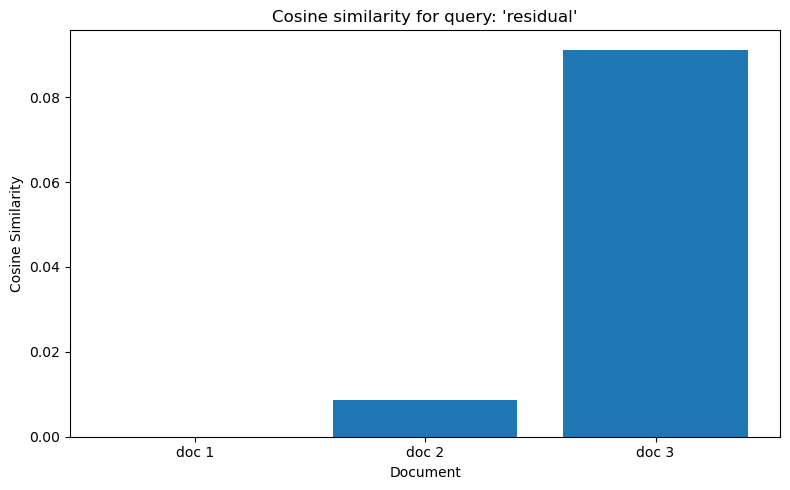

In [96]:
plt.figure(figsize=(8, 5))
plt.bar([f"doc {i+1}" for i in range(len(similarities[0]))], similarities[0])
plt.title(f"Cosine similarity for query: '{query}'")
plt.xlabel("Document")
plt.ylabel("Cosine Similarity")
plt.tight_layout()
plt.show()
